🚀 Initializing Advanced Clinical ISLES-2022 Analyzer...


Mapping Modalities:   0%|          | 0/250 [00:00<?, ?it/s]


✅ Successfully paired 144 complete patient cases.

📊 Extracting physical properties from NIfTI headers...


Analyzing Scans:   0%|          | 0/144 [00:00<?, ?it/s]


📈 Rendering Advanced Volume Distributions...


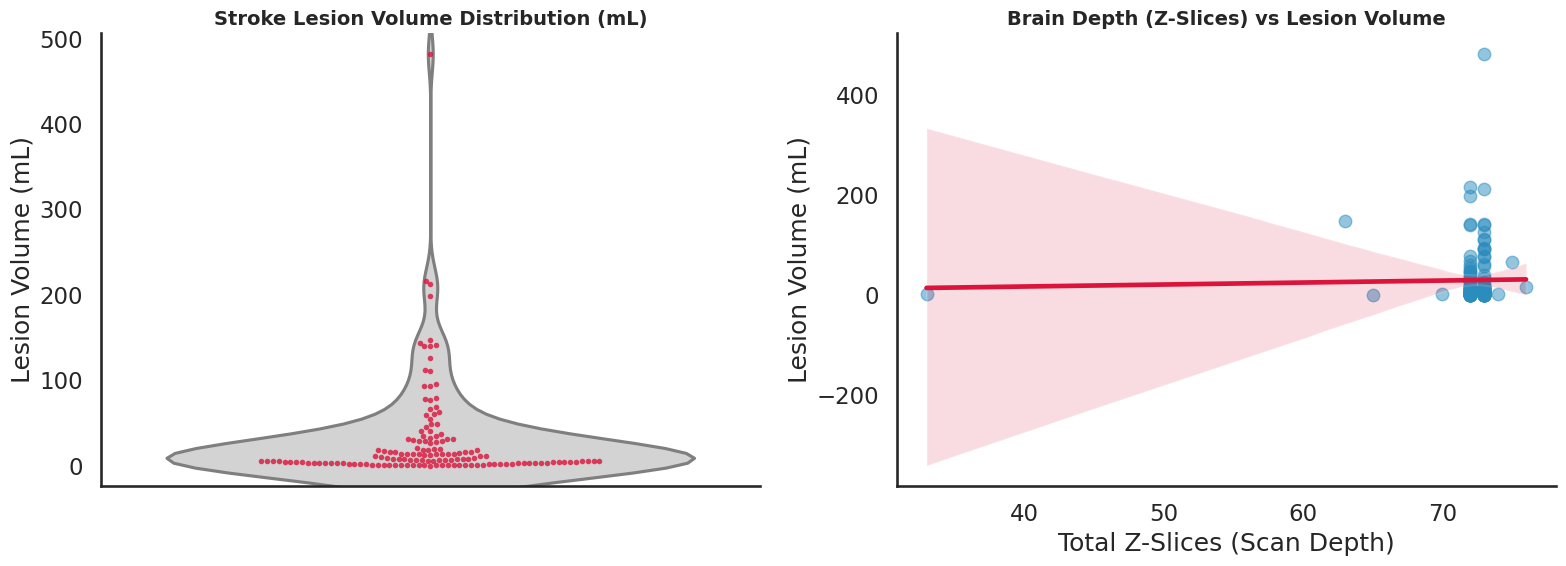


🧬 Profiling Lesion vs. Healthy Tissue Intensities...


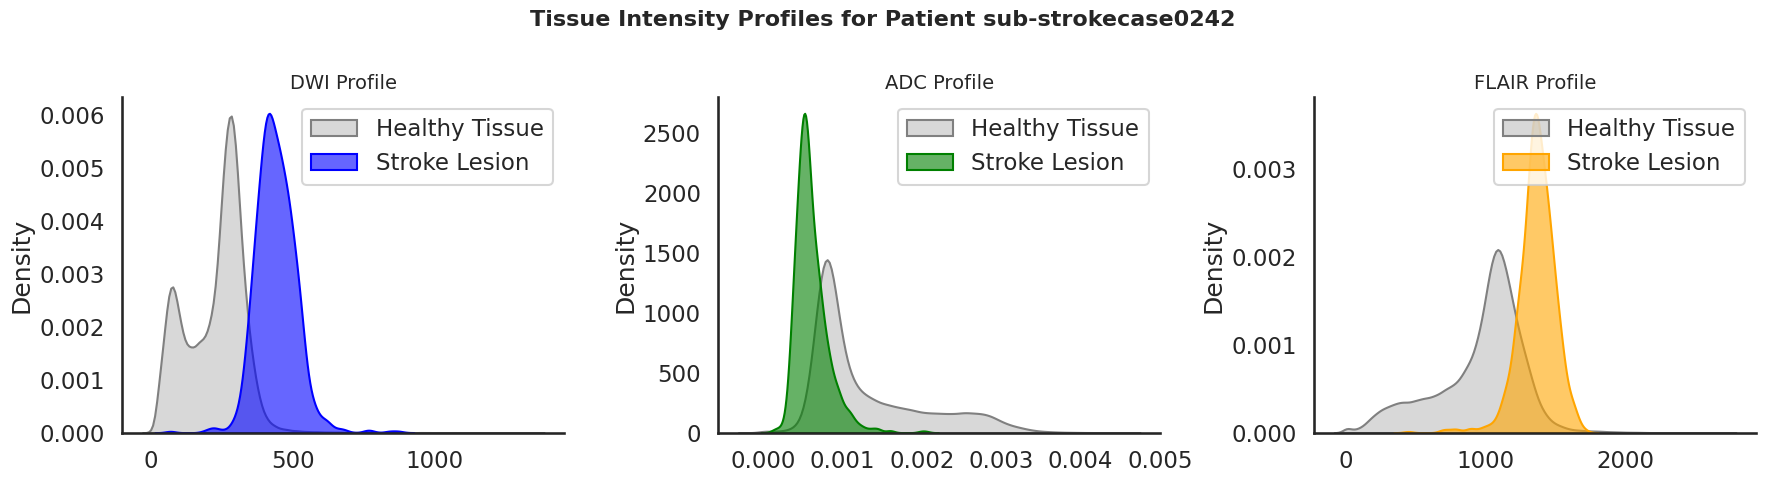


🖼️ Rendering Clinical Mosaic for largest lesion case...


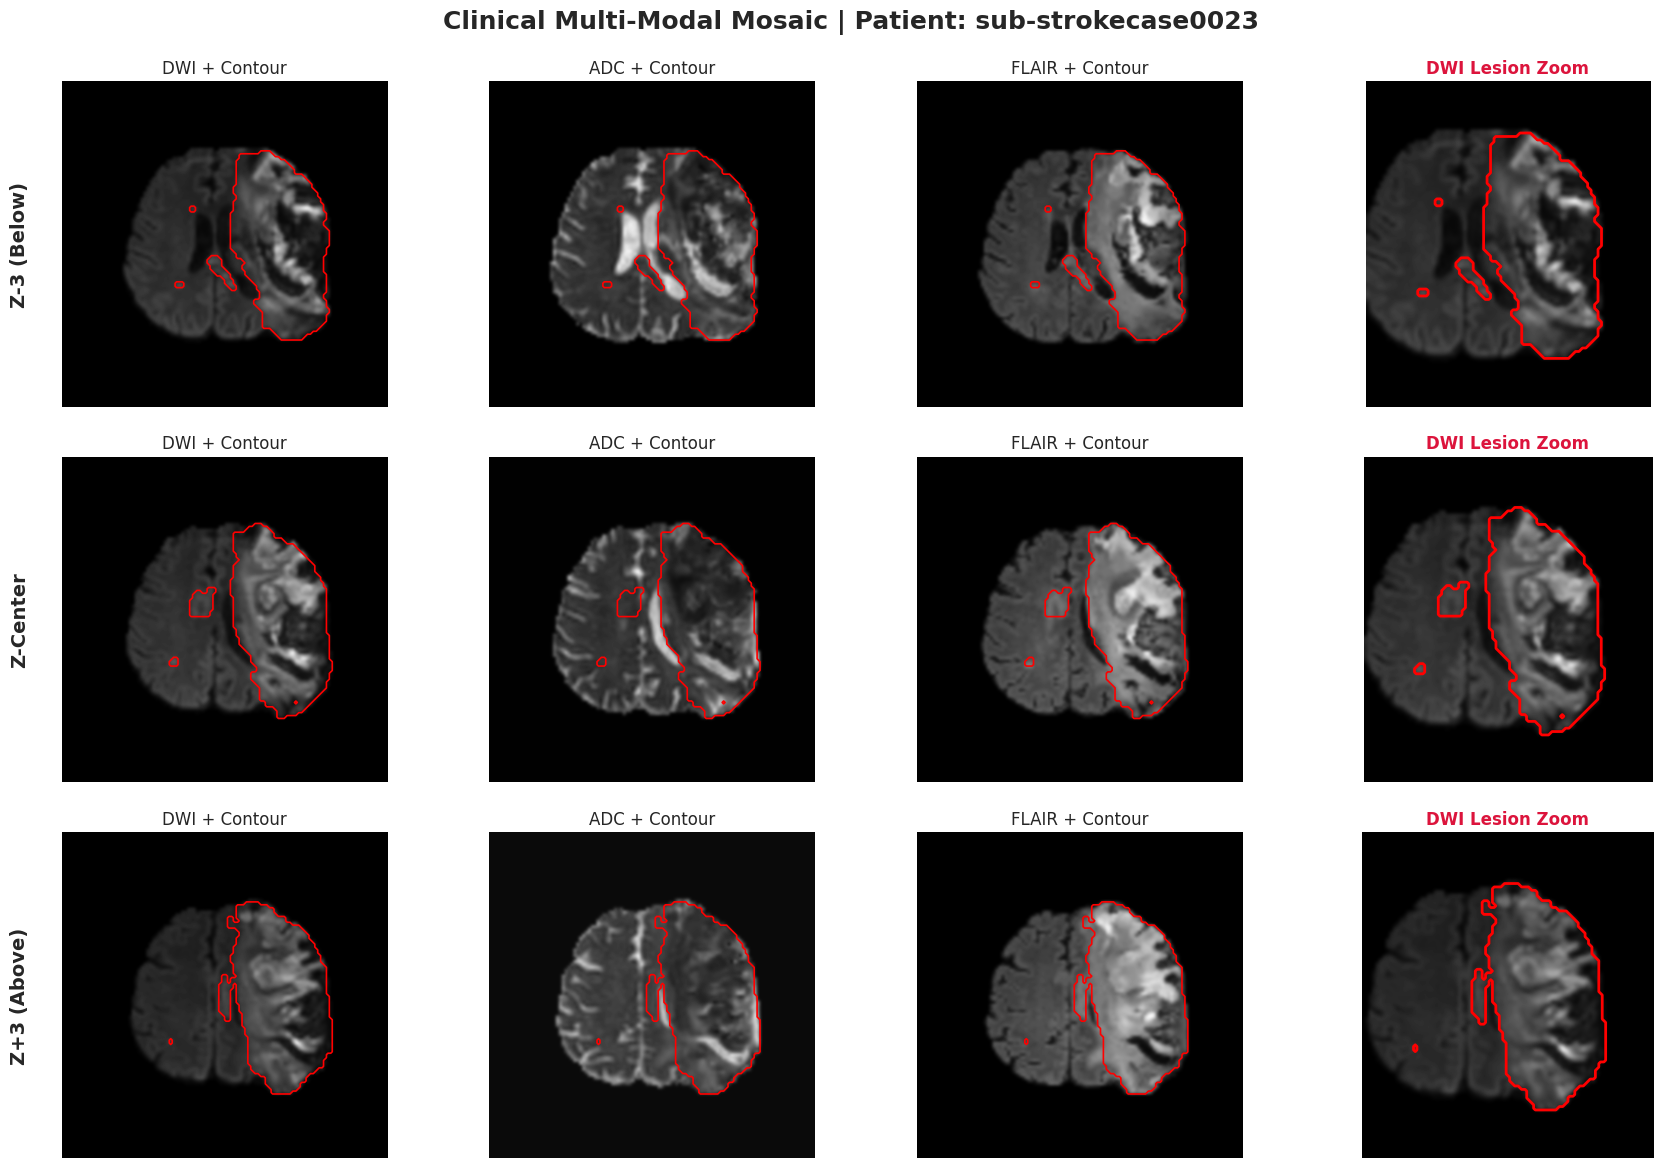


🖼️ Rendering Clinical Mosaic for a random case...


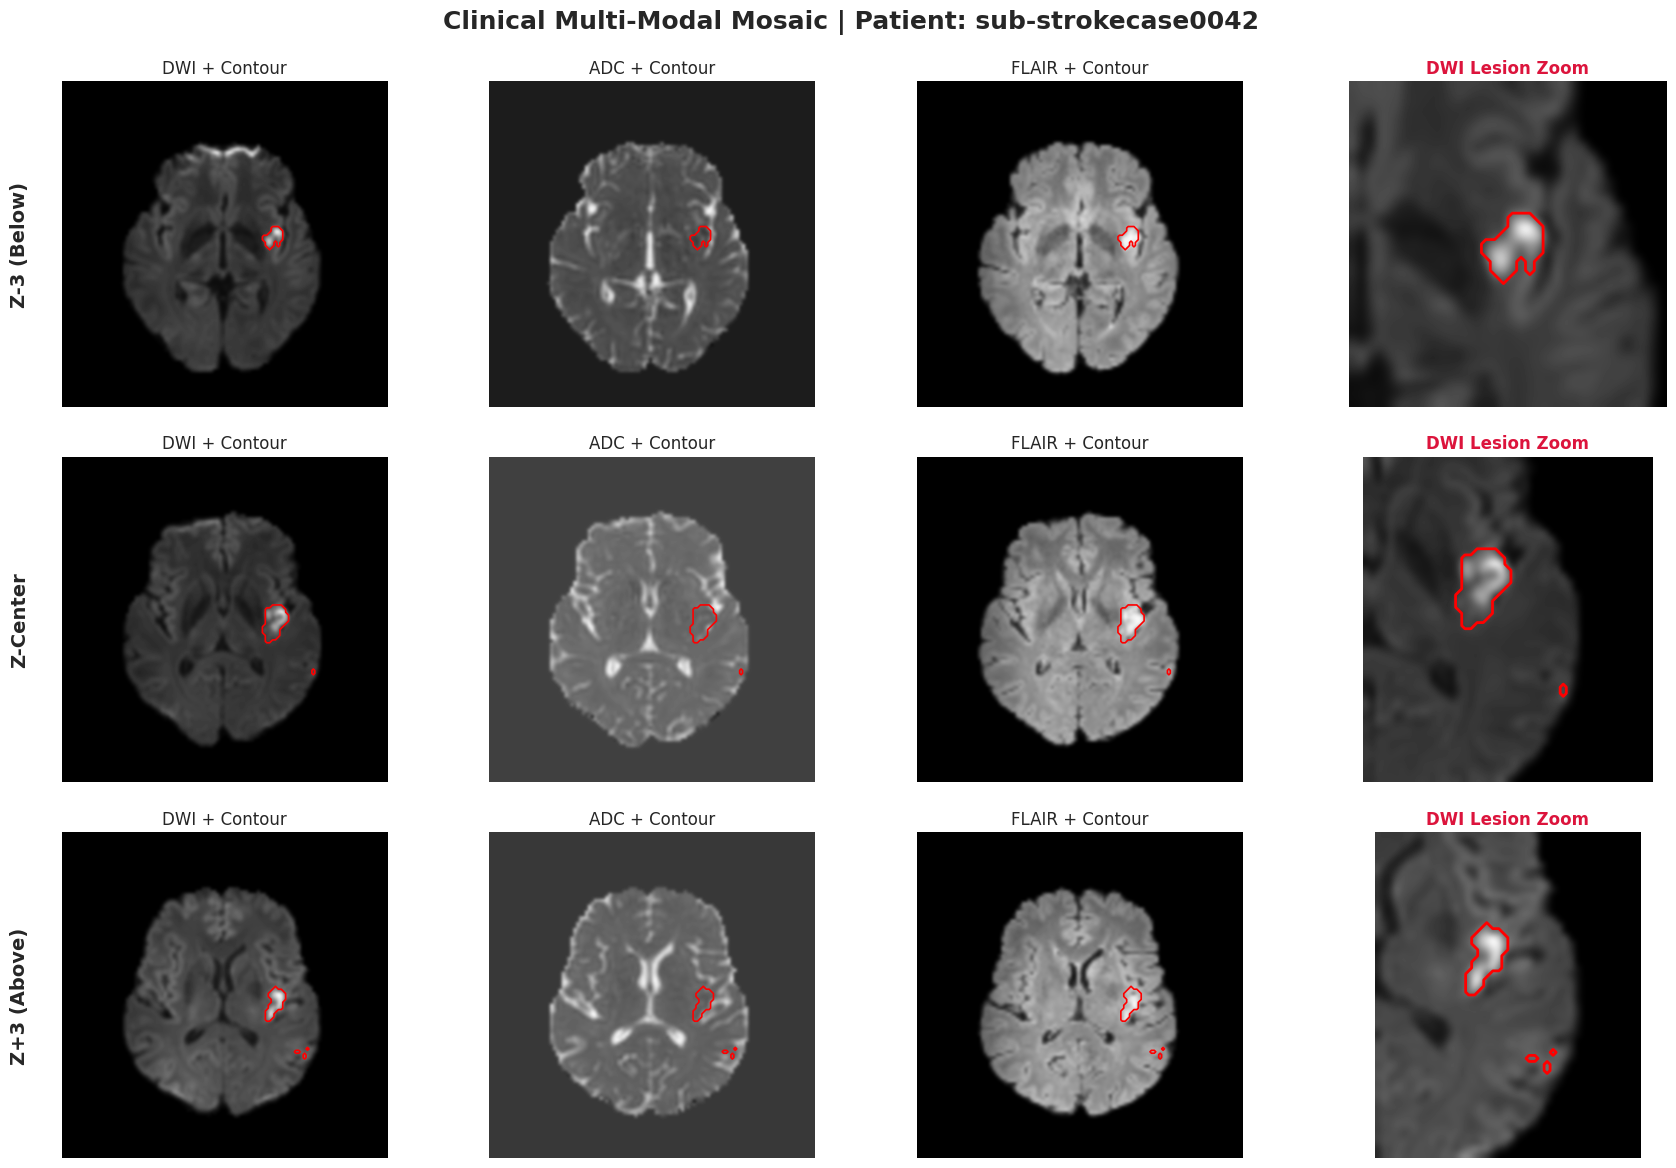

In [1]:
# =================================================================
# ISLES-2022: Advanced Clinical Exploratory Data Analysis (EDA)
# - FIXED: Resolves shape mismatch errors via nibabel resampling
# - FIXED: Suppresses Seaborn/Pandas FutureWarnings
# - Clinical-grade Contour overlays for lesion boundaries
# - Lesion vs. Healthy Tissue Intensity Profiling (KDEs)
# - Multi-slice 3D Mosaic Viewer (Progression across Z-axis)
# =================================================================

!pip install -q nibabel matplotlib seaborn pandas tqdm scikit-image

import os
import glob
import warnings
import numpy as np
import pandas as pd
import nibabel as nib
import nibabel.processing
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import measure
from tqdm.auto import tqdm

# Suppress annoying red FutureWarnings from Pandas/Seaborn
warnings.filterwarnings("ignore")

# --- 1. CONFIGURATION ---
SEARCH_ROOT = "/kaggle/input/datasets/prosenjitmondol/a-stroke-lesion-segmentation-dataset/ISLES-2022"
sns.set_theme(style="white", context="talk")

print("🚀 Initializing Advanced Clinical ISLES-2022 Analyzer...")

# --- 2. DATA DISCOVERY & PAIRING ---
def get_isles_dataframe(search_path: str):
    mask_files = glob.glob(os.path.join(search_path, "**", "*_msk.nii*"), recursive=True)
    data = []
    
    for mask_path in tqdm(mask_files, desc="Mapping Modalities"):
        filename = os.path.basename(mask_path)
        parts = filename.split("_")
        if len(parts) < 2: continue
            
        case_id = parts[0]   
        session_id = parts[1] 
        
        if "derivatives" in mask_path:
            base_dir = mask_path.split("derivatives")[0]
        else:
            base_dir = os.path.dirname(os.path.dirname(mask_path)) + os.sep
            
        case_folder = os.path.join(base_dir, case_id, session_id)
        
        def find_modality(pattern):
            matches = glob.glob(os.path.join(case_folder, "**", pattern), recursive=True)
            valid_matches = [m for m in matches if os.path.getsize(m) > 0]
            return valid_matches[0] if valid_matches else None

        flair = find_modality("*FLAIR.nii*")
        adc = find_modality("*adc.nii*")
        dwi = find_modality("*dwi.nii*")
        
        if flair and adc and dwi:
            data.append({
                "case_id": case_id, 
                "flair": flair, "adc": adc, "dwi": dwi, "mask": mask_path
            })
            
    return pd.DataFrame(data)

df = get_isles_dataframe(SEARCH_ROOT)
print(f"\n✅ Successfully paired {len(df)} complete patient cases.")

# --- 3. METADATA EXTRACTION ---
print("\n📊 Extracting physical properties from NIfTI headers...")
metrics = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Analyzing Scans"):
    try:
        dwi_img = nib.load(row['dwi'])
        mask_img = nib.load(row['mask'])
        
        header = dwi_img.header
        shape = dwi_img.shape
        voxel_sizes = header.get_zooms() 
        
        # We must align the mask to the DWI to get accurate voxel counts
        msk_r = nib.processing.resample_from_to(mask_img, dwi_img, order=0)
        mask_data = msk_r.get_fdata()
        
        lesion_voxels = np.sum(mask_data > 0)
        total_voxels = np.prod(shape)
        
        voxel_volume_mm3 = np.prod(voxel_sizes)
        lesion_volume_mm3 = lesion_voxels * voxel_volume_mm3
        
        metrics.append({
            "case_id": row['case_id'],
            "shape_x": shape[0], "shape_y": shape[1], "shape_z": shape[2],
            "voxel_z": voxel_sizes[2],
            "lesion_voxels": lesion_voxels,
            "lesion_ratio": (lesion_voxels / total_voxels) * 100,
            "lesion_volume_ml": lesion_volume_mm3 / 1000 
        })
    except Exception as e:
        pass

df_metrics = pd.DataFrame(metrics)

if len(df_metrics) > 0:
    # --- 4. ADVANCED VISUALIZATION: LESION DISTRIBUTION ---
    print("\n📈 Rendering Advanced Volume Distributions...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.violinplot(y=df_metrics['lesion_volume_ml'], ax=axes[0], color="lightgray", inner=None)
    sns.swarmplot(y=df_metrics['lesion_volume_ml'], ax=axes[0], color="crimson", size=4, alpha=0.8)
    axes[0].set_title('Stroke Lesion Volume Distribution (mL)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Lesion Volume (mL)')
    
    sns.regplot(data=df_metrics, x='shape_z', y='lesion_volume_ml', ax=axes[1], 
                scatter_kws={'alpha':0.5, 'color':'#2b8cbe'}, line_kws={'color':'crimson'})
    axes[1].set_title('Brain Depth (Z-Slices) vs Lesion Volume', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Total Z-Slices (Scan Depth)')
    axes[1].set_ylabel('Lesion Volume (mL)')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

    # --- 5. ADVANCED VISUALIZATION: HEALTHY VS LESION INTENSITY PROFILING ---
    print("\n🧬 Profiling Lesion vs. Healthy Tissue Intensities...")
    sample_case = df.iloc[0]
    
    # LOAD AND RESAMPLE TO MATCH SHAPES PERFECTLY
    dwi_nii = nib.load(sample_case['dwi'])
    dwi = dwi_nii.get_fdata()
    adc = nib.processing.resample_from_to(nib.load(sample_case['adc']), dwi_nii, order=1).get_fdata()
    flair = nib.processing.resample_from_to(nib.load(sample_case['flair']), dwi_nii, order=1).get_fdata()
    mask = nib.processing.resample_from_to(nib.load(sample_case['mask']), dwi_nii, order=0).get_fdata()
    
    # Isolate pixels
    healthy_mask = (mask == 0) & (dwi > 0.1) 
    lesion_mask = (mask > 0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Tissue Intensity Profiles for Patient {sample_case['case_id']}", fontsize=16, fontweight='bold')
    
    modalities = [
        (dwi, 'DWI', 'blue'),
        (adc, 'ADC', 'green'),
        (flair, 'FLAIR', 'orange')
    ]
    
    for idx, (mod_data, title, color) in enumerate(modalities):
        healthy_pixels = mod_data[healthy_mask]
        lesion_pixels = mod_data[lesion_mask]
        
        sns.kdeplot(healthy_pixels, ax=axes[idx], color='gray', fill=True, alpha=0.3, label='Healthy Tissue')
        sns.kdeplot(lesion_pixels, ax=axes[idx], color=color, fill=True, alpha=0.6, label='Stroke Lesion')
        
        axes[idx].set_title(f'{title} Profile', fontsize=14)
        axes[idx].legend()
        
    sns.despine()
    plt.tight_layout()
    plt.show()

    # --- 6. ADVANCED VISUALIZATION: MULTI-SLICE CLINICAL MOSAIC ---
    def plot_clinical_mosaic(case_row):
        # LOAD AND RESAMPLE TO MATCH SHAPES PERFECTLY
        dwi_nii = nib.load(case_row['dwi'])
        dwi = dwi_nii.get_fdata()
        adc = nib.processing.resample_from_to(nib.load(case_row['adc']), dwi_nii, order=1).get_fdata()
        flair = nib.processing.resample_from_to(nib.load(case_row['flair']), dwi_nii, order=1).get_fdata()
        mask = nib.processing.resample_from_to(nib.load(case_row['mask']), dwi_nii, order=0).get_fdata()
        
        # Find Z-slice with max lesion
        lesion_pixels_per_slice = [np.sum(mask[:, :, z]) for z in range(mask.shape[2])]
        best_z = np.argmax(lesion_pixels_per_slice)
        
        if lesion_pixels_per_slice[best_z] == 0:
            best_z = mask.shape[2] // 2
            
        slices_to_plot = [
            max(0, best_z - 3), 
            best_z, 
            min(mask.shape[2]-1, best_z + 3)
        ]
        
        fig, axes = plt.subplots(3, 4, figsize=(18, 12))
        fig.suptitle(f"Clinical Multi-Modal Mosaic | Patient: {case_row['case_id']}", fontsize=18, fontweight='bold')
        
        slice_labels = ["Z-3 (Below)", "Z-Center", "Z+3 (Above)"]
        
        for row_idx, z in enumerate(slices_to_plot):
            img_dwi = np.rot90(dwi[:, :, z])
            img_adc = np.rot90(adc[:, :, z])
            img_flair = np.rot90(flair[:, :, z])
            img_mask = np.rot90(mask[:, :, z])
            
            def plot_with_contour(ax, img, title):
                ax.imshow(img, cmap='gray', interpolation='bicubic')
                if np.max(img_mask) > 0: 
                    ax.contour(img_mask, levels=[0.5], colors='red', linewidths=1.2)
                ax.set_title(title, fontsize=12)
                ax.axis('off')
            
            axes[row_idx, 0].text(-0.1, 0.5, slice_labels[row_idx], transform=axes[row_idx, 0].transAxes, 
                                  fontsize=14, fontweight='bold', va='center', ha='right', rotation=90)
            
            plot_with_contour(axes[row_idx, 0], img_dwi, 'DWI + Contour')
            plot_with_contour(axes[row_idx, 1], img_adc, 'ADC + Contour')
            plot_with_contour(axes[row_idx, 2], img_flair, 'FLAIR + Contour')
            
            if np.max(img_mask) > 0:
                coords = np.argwhere(img_mask > 0)
                y_min, x_min = coords.min(axis=0)
                y_max, x_max = coords.max(axis=0)
                
                pad = 15
                y_min, y_max = max(0, y_min-pad), min(img_mask.shape[0], y_max+pad)
                x_min, x_max = max(0, x_min-pad), min(img_mask.shape[1], x_max+pad)
                
                axes[row_idx, 3].imshow(img_dwi[y_min:y_max, x_min:x_max], cmap='gray', interpolation='bicubic')
                axes[row_idx, 3].contour(img_mask[y_min:y_max, x_min:x_max], levels=[0.5], colors='red', linewidths=2)
                axes[row_idx, 3].set_title('DWI Lesion Zoom', fontsize=12, color='crimson', fontweight='bold')
            else:
                axes[row_idx, 3].imshow(np.zeros_like(img_dwi), cmap='gray')
                axes[row_idx, 3].set_title('No Lesion Present', fontsize=12)
            axes[row_idx, 3].axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()

    print("\n🖼️ Rendering Clinical Mosaic for largest lesion case...")
    largest_lesion_case_id = df_metrics.loc[df_metrics['lesion_volume_ml'].idxmax(), 'case_id']
    largest_case_row = df[df['case_id'] == largest_lesion_case_id].iloc[0]
    plot_clinical_mosaic(largest_case_row)

    print("\n🖼️ Rendering Clinical Mosaic for a random case...")
    random_case_row = df.sample(1).iloc[0]
    plot_clinical_mosaic(random_case_row)
else:
    print("❌ Critical Error: No valid scans were processed. Please check the Kaggle Dataset files.")